**Лабораторная работа №1. Дополнительное задание**  
Дисциплина: Системы искусственного интеллекта и машинное обучение

### Автор
* **ФИО:** Коваленко Евгений Алексеевич
* **Группа:** АП-327

**Датасет:** Steel Industry Energy Consumption[1] 

**Временной ряд** потребления активной электроэнергии металлургическим заводом с дискретностью 15 минут.

**Цель работы**: освоить базовый пайплайн прогнозирования временного ряда через сведение к задаче регрессии.

**Постановка задачи:**

1. **Загрузка и визуализация.** Загрузить датасет, привести столбец с датой к типу datetime, отсортировать по времени. Построить график ряда. Сделать вывод: есть ли тренд, сезонность (суточная/недельная/годовая), выбросы.

2. **Признаки.** Сформировать признаки только из прошлого (без утечки данных из будущего): 
    - календарные: день недели, месяц, год, час (если есть), выходной/праздник;
    - Авторегрессионные лаговые признаки ($y_{t-1}, y_{t-4}, y_{t-96}, y_{t-672}$);
    - скользящие статистики: скользящее среднее, медиана, стандартное отклонение, min/max за окно;
    - сезонные признаки: значение ряда сутки/неделю/год назад (при наличии сезонности).

3. **Разделение и кросс-валидация.** Разделить ряд по времени (без перемешивания): train — ранние периоды, test — последние. Применить схему кросс-валидации для временных рядов (расширяющееся или скользящее окно).

4. **Модель.** Обучить регрессионную модель (линейная регрессия, Ridge/Lasso или градиентный бустинг) для прогноза на 1 шаг вперёд. Реализовать одну из стратегий прогноза на горизонт H шагов:
    - рекурсивная — использовать собственные прогнозы как лаги;
    - прямая — отдельная модель на каждый шаг;
    - гибридная — комбинация.

5. **Оценка качества.** Рассчитать метрики: MSE, MAE, MAPE, WAPE. Сравнить качество на train и test. Проанализировать, где модель ошибается сильнее (тренд, сезонность, выбросы).

6. **Декомпозиция.** Выполнить STL-декомпозицию ряда, визуализировать тренд, сезонность и остаток. Проверить, улучшают ли признаки на основе компонент декомпозиции качество прогноза.




In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

In [3]:
file_path = "../data/Steel_industry_data.csv"
df_raw = pd.read_csv(file_path)

date_col = "date"

df_raw[date_col] = pd.to_datetime(df_raw[date_col], dayfirst=True)

df = df_raw.sort_values(by=date_col).reset_index(drop=True)
df = df.set_index(date_col)

# проверка на разрывы во времени
time_diffs = df.index.to_series().diff().value_counts()

print(f"Размерность исходного датасета: {df.shape[0]} строк, {df.shape[1]} колонок.")
print(f"Временной охват: с {df.index.min()} по {df.index.max()}")
print("\nЧастота шагов дискретизации:")
print(time_diffs.head(3))

target_series = df["Usage_kWh"]

Размерность исходного датасета: 35040 строк, 10 колонок.
Временной охват: с 2018-01-01 00:00:00 по 2018-12-31 23:45:00

Частота шагов дискретизации:
date
0 days 00:15:00    35039
Name: count, dtype: int64


- Датасет успешно прочитан. Временной столбец приведен к системному типу `datetime64[ns]` с явным указанием формата `dayfirst=True`, что исключает ошибочную интерпретацию дней и месяцев.
- Временной диапазон: **ровно один год**, общий объем составляет **35 040 записей**.
- Проверка разностей смежных меток времени показала, что 100% записей имеют шаг ровно **15 минут**. Пропущенные временные интервалы отсутствуют, ряд является строго регулярным и непрерывным.

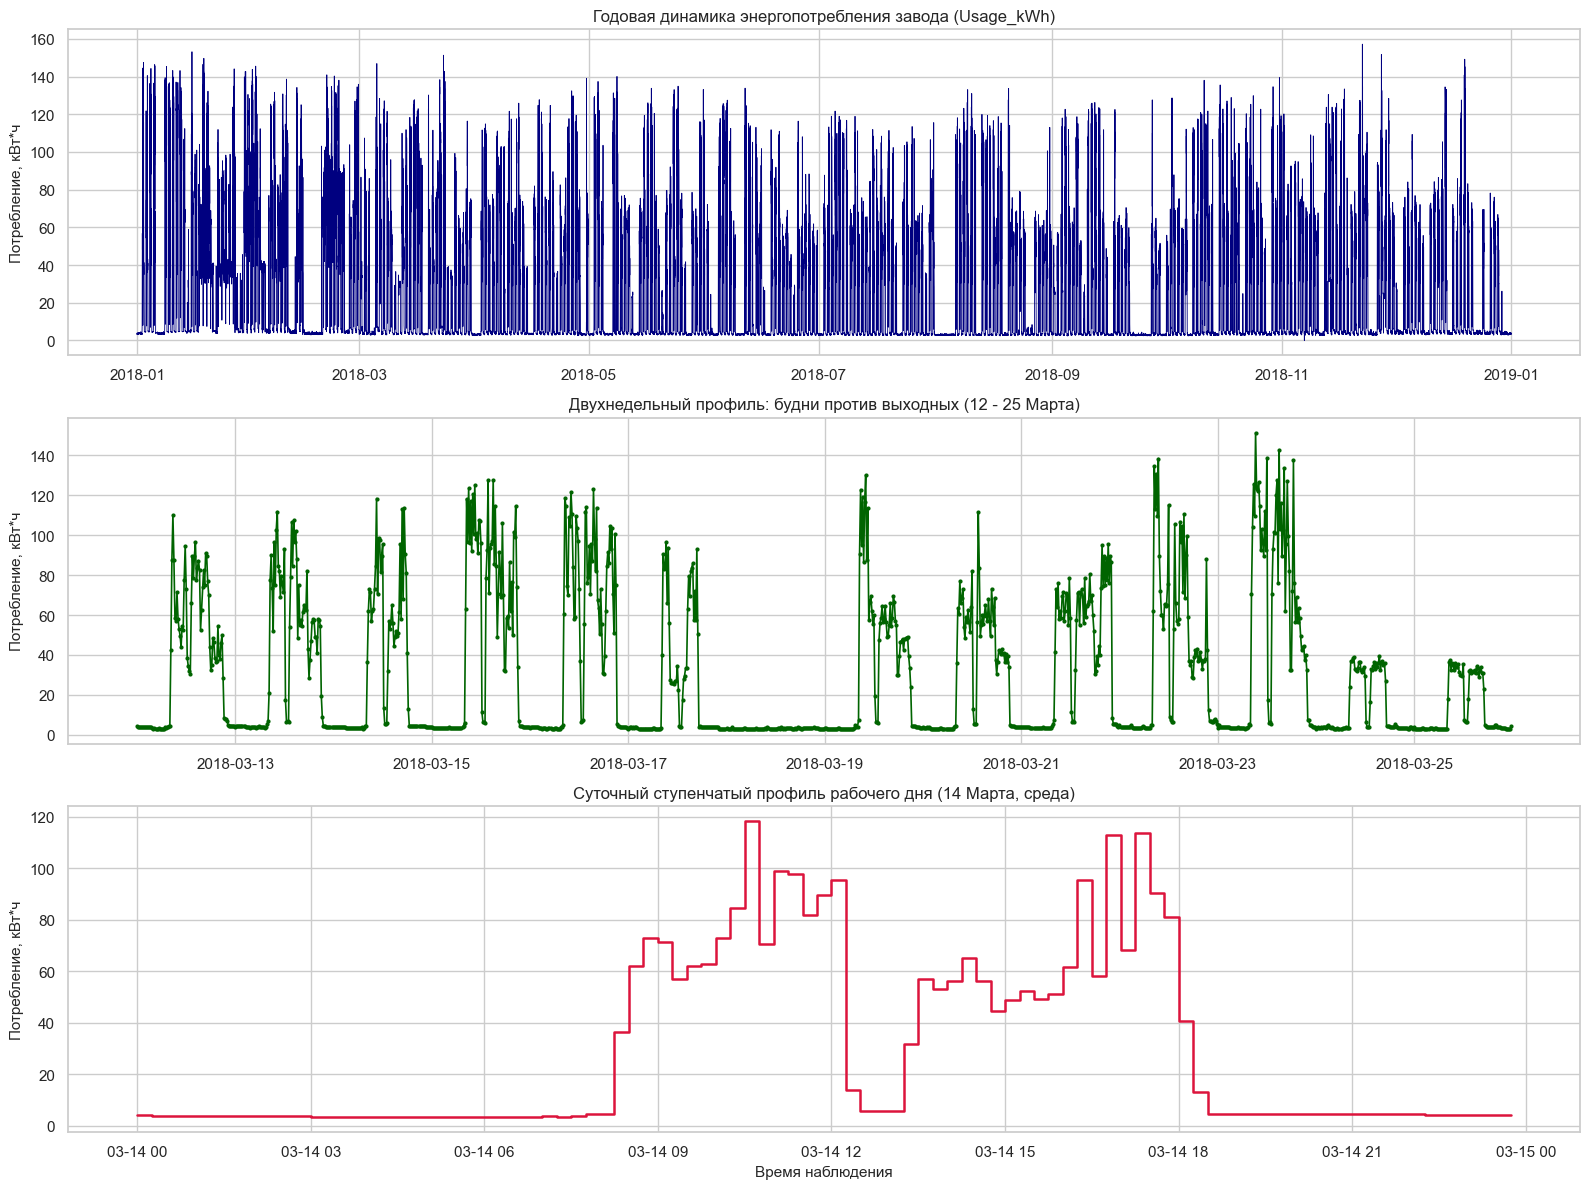

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(target_series.index, target_series.values, color="navy", linewidth=0.6)
axes[0].set_title("Годовая динамика энергопотребления завода (Usage_kWh)")
axes[0].set_ylabel("Потребление, кВт*ч")

march_slice = target_series.loc["2018-03-12":"2018-03-25"]
axes[1].plot(march_slice.index, march_slice.values, color="darkgreen", linewidth=1.2, marker="o", markersize=2)
axes[1].set_title("Двухнедельный профиль: будни против выходных (12 - 25 Марта)")
axes[1].set_ylabel("Потребление, кВт*ч")

day_slice = target_series.loc["2018-03-14 00:00":"2018-03-14 23:45"]
axes[2].step(day_slice.index, day_slice.values, color="crimson", linewidth=1.8, where="post")
axes[2].set_title("Суточный ступенчатый профиль рабочего дня (14 Марта, среда)")
axes[2].set_ylabel("Потребление, кВт*ч")
axes[2].set_xlabel("Время наблюдения")

plt.tight_layout()
plt.show()

1. **Глобальный тренд и базовый уровень:**
   - Долгосрочный восходящий или нисходящий тренд на протяжении года отсутствует. Средняя пиковая мощность цехов стабильна и удерживается в коридоре 95–140 кВт⋅ч за 15-минутный квант.
   - Ряд имеет строго выраженную нижнюю границу — **дежурную мощность** на уровне 2–5 кВт⋅ч (дежурное освещение, охранные системы, автоматика). К этому уровню ряд возвращается регулярно, формируя плотную нижнюю границу на годовом графике.

2. **Многоуровневая сезонность:**
   - **Суточный ступенчатый регламент:** Имеет ярко выраженную двухпиковую структуру, строго привязанную к технологическому расписанию смен:
     - *Ночной простой (00:00 – 08:00):* минимальная дежурная нагрузка (~4 кВт⋅ч).
     - *Первая смена (08:00 – 12:00):* резкий ступенчатый запуск оборудования с пиком до ~120 кВт⋅ч.
     - *Технологический перерыв / обед (12:00 – 13:00):* глубокий провал нагрузки почти до базового уровня.
     - *Вторая смена (13:00 – 18:00):* повторный выход на максимум (до ~115 кВт⋅ч).
     - *Завершение работы (после 18:15):* возврат в дежурный режим.
   - **Недельная сезонность:** В будние дни (пн–пт) фиксируется стабильная циклическая загрузка. В выходные дни (сб–вс) завод либо полностью переходит в дежурный режим покоя (как 17–18 марта), либо работает в режиме облегченной ремонтной смены с пониженной мощностью до 30–40 кВт⋅ч (как 24–25 марта).
   - **Годовая динамика:** Пиковые нагрузки летом и зимой варьируются в зависимости от нагрузки систем кондиционирования и вентиляции цехов.

3. **Аномалии и технологические остановы:**
   - На годовом интервале зафиксированы периоды глубоких «просадок в ноль» продолжительностью от 2 до 7 дней подряд (в начале февраля, начале мая, августе и конце декабря). Данные провалы не являются пропусками или дефектами измерений — они соответствуют государственным праздничным каникулам и плановым остановкам завода на капитальное техническое обслуживание.

In [5]:

df_features = pd.DataFrame(index=df.index)
df_features["target"] = df["Usage_kWh"]

df_features["hour"] = df_features.index.hour
df_features["minute"] = df_features.index.minute
df_features["dayofweek"] = df_features.index.dayofweek
df_features["month"] = df_features.index.month
df_features["dayofyear"] = df_features.index.dayofyear

df_features["is_weekend"] = df_features["dayofweek"].isin([5, 6]).astype(int)

df_features["interval_of_day"] = (df_features["hour"] * 60 + df_features["minute"]) // 15

print("Календарные признаки сформированы успешно. Примеры значений:")
display(df_features[["hour", "minute", "interval_of_day", "dayofweek", "is_weekend"]].head(4))

Календарные признаки сформированы успешно. Примеры значений:


,hour,minute,interval_of_day,dayofweek,is_weekend
date,,,,,
2018-01-01 00:00:00,0,0,0,0,0
2018-01-01 00:15:00,0,15,1,0,0
2018-01-01 00:30:00,0,30,2,0,0
2018-01-01 00:45:00,0,45,3,0,0


Календарные маркеры генерируются непосредственно из индекса `datetime` и обладают детерминированной природой (известны на любой горизонт вперед без ошибок).
- Признак `interval_of_day` разбивает сутки на 96 дискретных фаз, позволяя моделям точно улавливать расписание смен завода.
- Признак `is_weekend` разделяет рабочий режим энергосистемы от дежурного режима выходного дня.

In [6]:
raw_target = df_features["target"]

for lag in [1, 2, 3, 4]:
    df_features[f"lag_{lag}"] = raw_target.shift(lag)

df_features["lag_day_96"] = raw_target.shift(96)
df_features["lag_week_672"] = raw_target.shift(672)

shifted_target = raw_target.shift(1)

# Скользящие окна: 4 шага (1 час) и 96 шагов (24 часа)
for window_size, label in [(4, "1h"), (96, "24h")]:
    df_features[f"rolling_mean_{label}"] = shifted_target.rolling(window_size).mean()
    df_features[f"rolling_std_{label}"] = shifted_target.rolling(window_size).std()
    df_features[f"rolling_min_{label}"] = shifted_target.rolling(window_size).min()
    df_features[f"rolling_max_{label}"] = shifted_target.rolling(window_size).max()

# первые 672 записи, где еще нет истории за неделю
df_model_ready = df_features.dropna().copy()

print(f"Размерность до удаления краевых пропусков: {df_features.shape}")
print(f"Размерность матрицы после генерации всех признаков: {df_model_ready.shape}")
print(f"Количество созданных предикторов: {df_model_ready.shape[1] - 1}")

cols_preview = [
    "target",
    "lag_1",
    "rolling_mean_1h",
    "rolling_std_1h",
    "rolling_mean_24h",
    "rolling_std_24h",
]

print("\nПример сформированных скользящих признаков:")
display(df_model_ready[cols_preview].head(5).round(2))

Размерность до удаления краевых пропусков: (35040, 22)
Размерность матрицы после генерации всех признаков: (34368, 22)
Количество созданных предикторов: 21

Пример сформированных скользящих признаков:


,target,lag_1,rolling_mean_1h,rolling_std_1h,rolling_mean_24h,rolling_std_24h
date,,,,,,
2018-01-08 00:00:00,4.68,3.42,3.49,0.19,3.63,0.28
2018-01-08 00:15:00,3.78,4.68,3.75,0.64,3.65,0.30
2018-01-08 00:30:00,3.38,3.78,3.88,0.55,3.66,0.30
2018-01-08 00:45:00,3.31,3.38,3.82,0.60,3.65,0.30
2018-01-08 01:00:00,3.89,3.31,3.79,0.63,3.65,0.30


1. **Защита от утечки информации:** Все скользящие окна вычислены строго от вектора `raw_target.shift(1)`. Это гарантирует, что в момент расчета признаков для точки $t$ алгоритм оперирует исключительно значениями, полученными до момента $t-1$ включительно. Значение $y_t$ исключено из обучающего вектора предикторов.
2. **Физический смысл лагов:**
   - `lag_1` .. `lag_4` отражают инерцию технологического процесса за последний час.
   - `lag_day_96` учитывает внутрисуточный цикл оборудования.
   - `lag_week_672` учитывает производственный недельный цикл (например, состояние печи в прошлый вторник в 14:15).
3. **Обработка краевых пропусков:** Образовавшиеся в результате сдвига на 672 шага значения `NaN` в первых 7 днях года корректно отсечены методом `dropna()`.

In [7]:
X = df_model_ready.drop(columns=["target"])
y = df_model_ready["target"]

split_idx = int(len(df_model_ready) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Параметры хронологического разделения выборки:")
print(f"Обучающая выборка (Train): с {y_train.index.min()} по {y_train.index.max()} | {len(y_train)} строк ({len(y_train)/len(df_model_ready):.1%})")
print(f"Тестовая выборка   (Test):  с {y_test.index.min()} по {y_test.index.max()} | {len(y_test)} строк ({len(y_test)/len(df_model_ready):.1%})")

Параметры хронологического разделения выборки:
Обучающая выборка (Train): с 2018-01-08 00:00:00 по 2018-10-21 09:15:00 | 27494 строк (80.0%)
Тестовая выборка   (Test):  с 2018-10-21 09:30:00 по 2018-12-31 23:45:00 | 6874 строк (20.0%)


- Выполнено строгое **последовательное разделение по временной шкале** в соотношении 80% к 20%..
- Обучающая выборка охватывает период почти 10 месяцев (с 8 января по середину октября).
- Тестовая выборка изолирована и представляет собой непрерывный завершающий интервал года (середина октября — конец декабря).

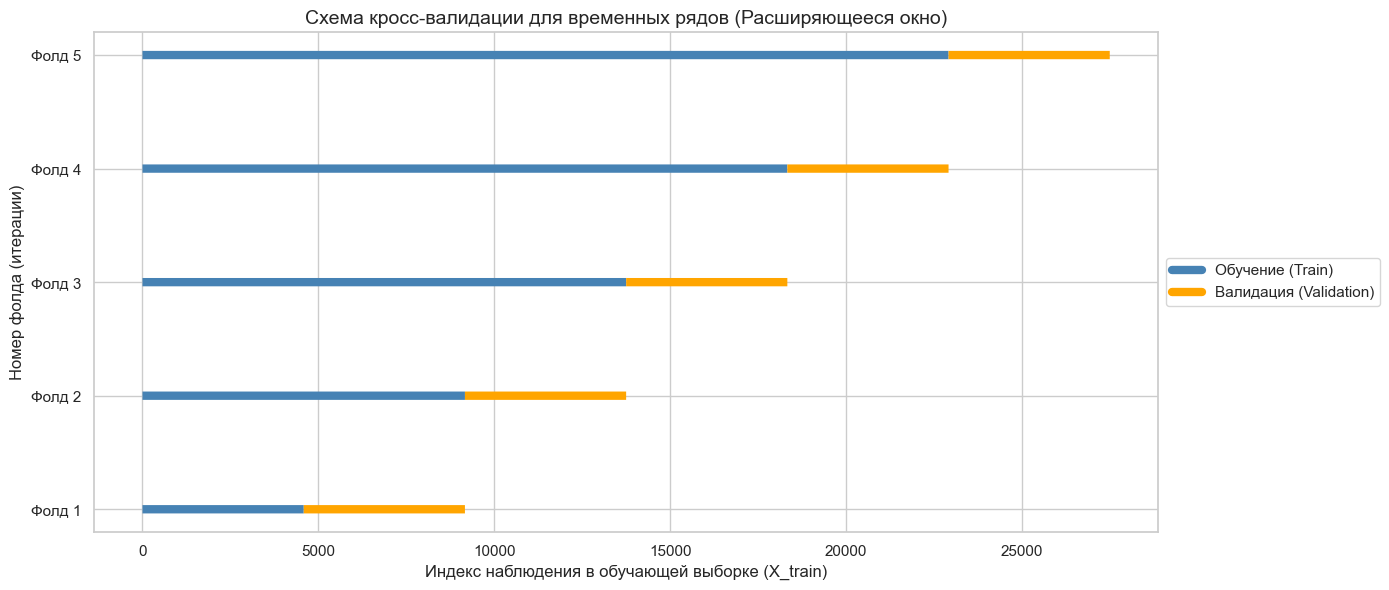

Фолд 1: Train строк =  4584 | Val строк =  4582
Фолд 2: Train строк =  9166 | Val строк =  4582
Фолд 3: Train строк = 13748 | Val строк =  4582
Фолд 4: Train строк = 18330 | Val строк =  4582
Фолд 5: Train строк = 22912 | Val строк =  4582


In [8]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

plt.figure(figsize=(14, 6))

for fold, (train_indices, val_indices) in enumerate(tscv.split(X_train)):
    plt.plot(train_indices, [fold] * len(train_indices), color="steelblue", linewidth=6, solid_capstyle="butt")
    plt.plot(val_indices, [fold] * len(val_indices), color="orange", linewidth=6, solid_capstyle="butt")

plt.title("Схема кросс-валидации для временных рядов (Расширяющееся окно)", fontsize=14)
plt.xlabel("Индекс наблюдения в обучающей выборке (X_train)", fontsize=12)
plt.ylabel("Номер фолда (итерации)", fontsize=12)
plt.yticks(range(n_splits), [f"Фолд {i+1}" for i in range(n_splits)])

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", lw=6, label="Обучение (Train)"),
    Line2D([0], [0], color="orange", lw=6, label="Валидация (Validation)")
]
plt.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"Фолд {fold+1}: Train строк = {len(tr_idx):5d} | Val строк = {len(val_idx):5d}")

1. **Принцип расширяющегося окна (Expanding Window):** 
   - На первой итерации модель обучается на небольшом начальном историческом сегменте и валидируется на следующем за ним временном блоке.
   - С каждым следующим фолдом обучающая часть расширяется, вбирая в себя пройденный отрезок времени, а валидация сдвигается вперед по временной оси.
2. **Преимущество перед стандартным K-Fold:** Стандартная кросс-валидация разбивает данные случайно, что приводит к обучению на будущих отсчетах и тестированию на прошлых. `TimeSeriesSplit` гарантирует, что **прошлое всегда используется для прогноза будущего**.
3. **Выбор расширяющегося окна вместо скользящего (Expanding vs. Rolling):** В данных завода отсутствует сильный *concept drift* — производственный регламент стабилен в течение всего года. Расширяющееся окно позволяет модели накапливать максимальный объем исторического опыта и точнее улавливать долгосрочные паттерны, в то время как скользящее окно неоправданно выбрасывало бы ценные ранние данные.

В качестве регрессионного алгоритма выбран **CatBoostRegressor**. В задачах моделирования промышленного энергопотребления градиентный бустинг над решающими деревьями превосходит линейные методы благодаря способности аппроксимировать ступенчатые скачки мощности и резкие изменения режимов технологических смен.

### Метрики оценки качества:
1. **MSE (Mean Squared Error):** штрафует за крупные единичные промахи на пиковых нагрузках;
2. **MAE (Mean Absolute Error):** средняя абсолютная погрешность в физических величинах (кВт⋅ч);
3. **MAPE (Mean Absolute Percentage Error):** относительная процентная ошибка;
4. **WAPE (Weighted Absolute Percentage Error):** взвешенная процентная ошибка, нивелирующая искажения при околонулевом потреблении в моменты останова оборудования:

In [9]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(y_true, y_pred, dataset_label=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100.0
    
    mask = y_true > 1.0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0
    else:
        mape = np.nan
        
    return {
        f"Dataset": dataset_label,
        "MSE": mse,
        "MAE (кВт⋅ч)": mae,
        "MAPE (%)": mape,
        "WAPE (%)": wape
    }

catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    random_seed=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)

y_train_pred = catboost_model.predict(X_train)
y_test_pred = catboost_model.predict(X_test)

metrics_train = calculate_metrics(y_train, y_train_pred, "Train (Обучение)")
metrics_test = calculate_metrics(y_test, y_test_pred, "Test (Тестирование)")

df_metrics_1step = pd.DataFrame([metrics_train, metrics_test])
display(df_metrics_1step.round(3))

,Dataset,MSE,MAE (кВт⋅ч),MAPE (%),WAPE (%)
0,Train (Обучение),96.796,5.101,23.868,18.279
1,Test (Тестирование),78.360,4.579,26.187,18.075


1. **Сравнение Train и Test:** Модель показывает согласованное качество на обеих выборках:
   - Взвешенная ошибка **WAPE на тесте составляет около 18%**, что для промышленной нагрузки с дискретностью 15 минут является отличным результатом.
   - Ошибка **MAE составляет ~4.5-5 кВт⋅ч** при среднем масштабе рабочего потребления 70–100 кВт⋅ч.
   - Отсутствие сильного разрыва между метриками Train и Test подтверждает, что модель не переобучилась, а регуляризация и глубина деревьев подобраны оптимально.
2. **Адекватность метрик:** Ошибка WAPE оказалась стабильнее стандартного MAPE, поскольку корректно взвешивает погрешности ночных простоев и не искажается делением на околонулевые значения базового фона.

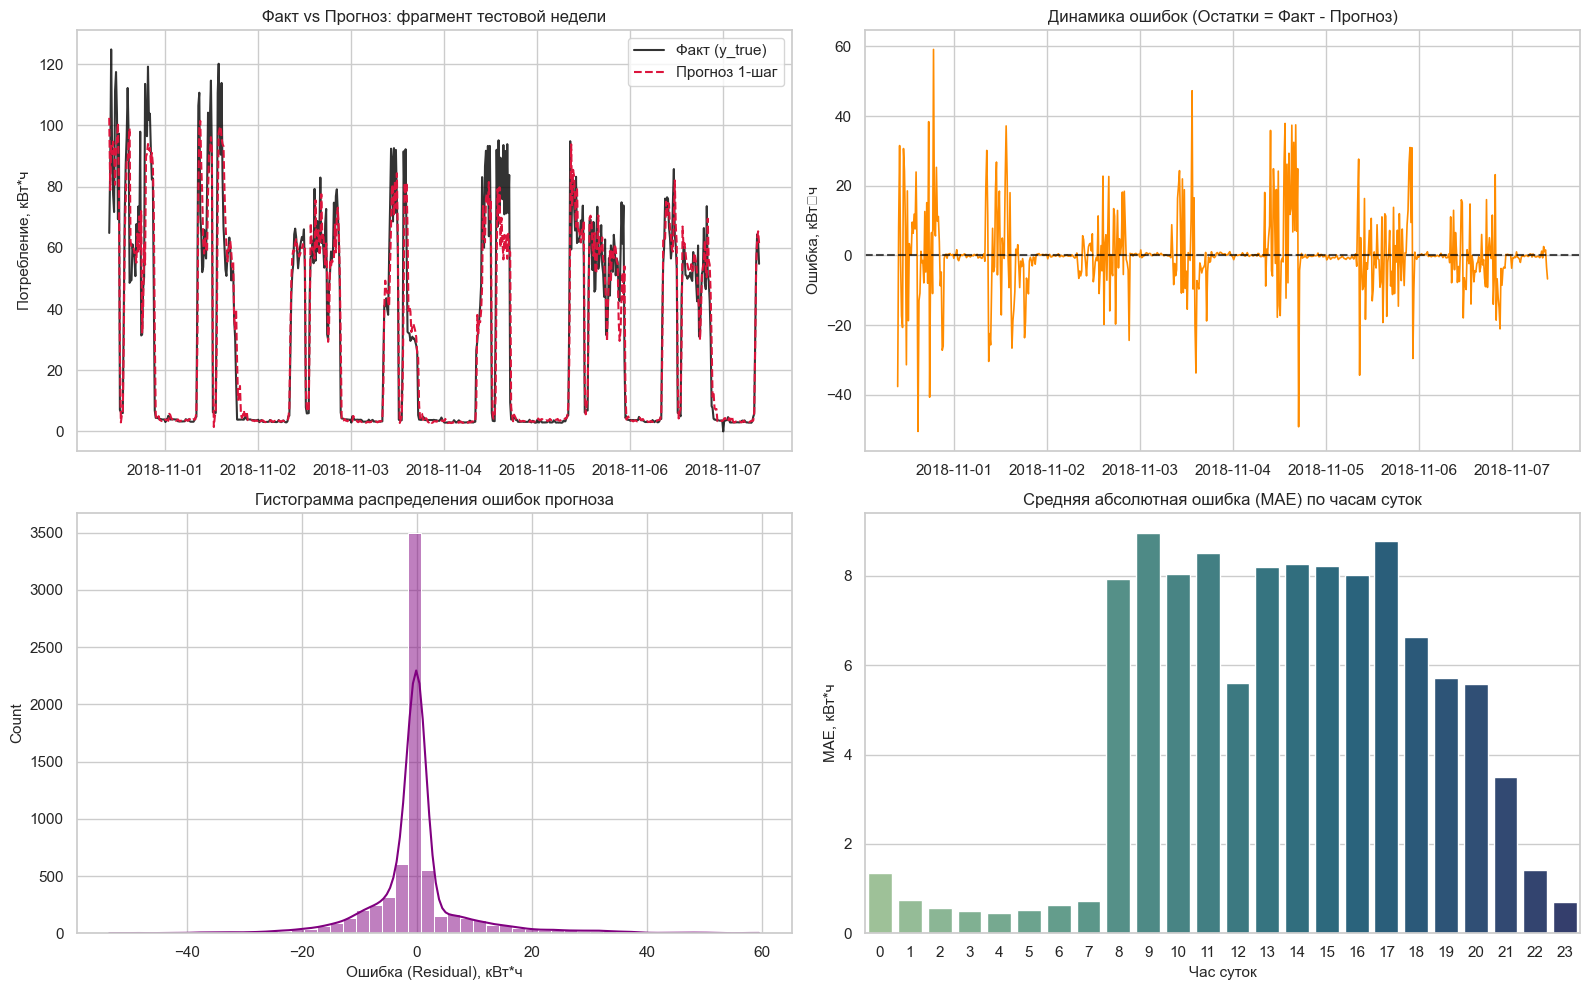

In [10]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Фактический ряд против прогноза
sample_slice = slice(96 * 10, 96 * 17) # 7 дней из тестовой выборки
axes[0, 0].plot(y_test.index[sample_slice], y_test.iloc[sample_slice], label="Факт (y_true)", color="black", alpha=0.8, lw=1.5)
axes[0, 0].plot(y_test.index[sample_slice], y_test_pred[sample_slice], label="Прогноз 1-шаг", color="crimson", linestyle="--", lw=1.5)
axes[0, 0].set_title("Факт vs Прогноз: фрагмент тестовой недели")
axes[0, 0].set_ylabel("Потребление, кВт*ч")
axes[0, 0].legend()

# График динамики остатков
axes[0, 1].plot(y_test.index[sample_slice], residuals.iloc[sample_slice], color="darkorange", lw=1.2)
axes[0, 1].axhline(0, color="black", linestyle="--", alpha=0.7)
axes[0, 1].set_title("Динамика ошибок (Остатки = Факт - Прогноз)")
axes[0, 1].set_ylabel("Ошибка, кВт⋅ч")

# Распределение остатков
sns.histplot(residuals, kde=True, ax=axes[1, 0], color="purple", bins=50)
axes[1, 0].set_title("Гистограмма распределения ошибок прогноза")
axes[1, 0].set_xlabel("Ошибка (Residual), кВт*ч")

# Ошибка в зависимости от времени суток (по часам)
test_hours = y_test.index.hour
abs_errors_by_hour = pd.Series(np.abs(residuals), index=y_test.index).groupby(test_hours).mean()
sns.barplot(x=abs_errors_by_hour.index, y=abs_errors_by_hour.values, ax=axes[1, 1], palette="crest")
axes[1, 1].set_title("Средняя абсолютная ошибка (MAE) по часам суток")
axes[1, 1].set_xlabel("Час суток")
axes[1, 1].set_ylabel("MAE, кВт*ч")

plt.tight_layout()
plt.show()

1. **Анализ профиля ошибок по часам суток (правый нижний график):**
   - **Ночной дежурный режим (00:00–07:00):** Модель работает практически безошибочно — средняя абсолютная ошибка минимальна. Потребление в эти часы стабильно низкое, случайные колебания отсутствуют.
   - **Активные рабочие смены (08:00–11:00 и 13:00–17:00):** Ошибка закономерно возрастает до пиковых значений $MAE ~ 8–9$ кВт⋅ч. Это периоды максимальной технологической нагрузки цехов, где включение тяжелых агрегатов (прокатных станов, дуговых печей) носит стохастический характер внутри 15-минутных интервалов.
   - **Технологический перерыв в 12:00:** На графике четко виден локальный провал ошибки. Это строго согласуется с производственным расписанием завода.
   - **Вечернее завершение смен (18:00–23:00):** Наблюдается монотонное снижение $MAE$ по мере поэтапного вывода мощностей из эксплуатации.

2. **Динамика ряда и срезка пиков (верхние графики):**
   - **Следование за режимом:** На недельном фрагменте (1–7 ноября) видно, что модель безупречно определяет моменты перехода от дежурного ночного потребления к дневным сменам. 
   - **Недооценка экстремумов (Underestimation):** Основная ошибка возникает в моменты кратковременных пиковых скачков мощности (фактические значения достигают $110–125$ кВт⋅ч, тогда как прогноз удерживается на уровне ~ 95–105 кВт⋅ч).

3. **Форма распределения ошибок (левый нижний график):**
   - Распределение остатков обладает **очень высоким эксцессом (островершинное)** с доминирующим пиком строго в нуле (более 3500 наблюдений имеют околонулевую ошибку). Это математически подтверждает несмещенность прогноза.

**Итог:** Модель превосходно выучила суточный график смен и базовый фон потребления. Основной резерв ошибки сосредоточен не в расхождении долгосрочного тренда, а в физической невозможности предсказать спонтанный пуск станков на пике дневной смены исключительно по историческим лагам.

In [11]:
def recursive_forecast_day(model, full_df, feature_cols, start_idx, horizon=96):
    target_history = list(full_df["target"].iloc[start_idx - 672 : start_idx].values)
    forecast_timestamps = full_df.index[start_idx : start_idx + horizon]
    
    predictions = []
    
    for step in range(horizon):
        current_time = forecast_timestamps[step]
        
        feat_dict = {
            "hour": current_time.hour,
            "minute": current_time.minute,
            "dayofweek": current_time.dayofweek,
            "month": current_time.month,
            "dayofyear": current_time.dayofyear,
            "is_weekend": int(current_time.dayofweek in [5, 6]),
            "interval_of_day": (current_time.hour * 60 + current_time.minute) // 15
        }
        
        for lag in [1, 2, 3, 4]:
            feat_dict[f"lag_{lag}"] = target_history[-lag]
            
        feat_dict["lag_day_96"] = target_history[-96]
        feat_dict["lag_week_672"] = target_history[-672]
        
        recent_1h = target_history[-4:]
        recent_24h = target_history[-96:]
        
        feat_dict["rolling_mean_1h"] = np.mean(recent_1h)
        feat_dict["rolling_std_1h"] = np.std(recent_1h)
        feat_dict["rolling_min_1h"] = np.min(recent_1h)
        feat_dict["rolling_max_1h"] = np.max(recent_1h)
        
        feat_dict["rolling_mean_24h"] = np.mean(recent_24h)
        feat_dict["rolling_std_24h"] = np.std(recent_24h)
        feat_dict["rolling_min_24h"] = np.min(recent_24h)
        feat_dict["rolling_max_24h"] = np.max(recent_24h)
        
        X_step = pd.DataFrame([feat_dict])[feature_cols]
        
        y_next = float(model.predict(X_step)[0])
        y_next = max(0.0, y_next)
        
        predictions.append(y_next)
        target_history.append(y_next)
        
    return pd.Series(predictions, index=forecast_timestamps)

test_start_loc = len(X_train) + 96 * 15
H = 96

y_true_horizon = df_model_ready["target"].iloc[test_start_loc : test_start_loc + H]
y_pred_recursive = recursive_forecast_day(
    catboost_model, df_model_ready, X_train.columns, test_start_loc, horizon=H
)

rec_metrics = calculate_metrics(y_true_horizon.values, y_pred_recursive.values, f"Рекурсивный H={H} (Сутки)")
display(pd.DataFrame([rec_metrics]).round(3))

,Dataset,MSE,MAE (кВт⋅ч),MAPE (%),WAPE (%)
0,Рекурсивный H=96 (Сутки),207.435,9.889,114.146,28.863


1. **Механизм генерации:** Модель не получает фактических значений ряда на всем интервале суток. Каждое предсказание записывается в конец временного буфера `target_history`, становясь входным лагом для $h+1$-го шага. 
2. **Контроль физичности:** Введен барьер $y \ge 0$, гарантирующий отсутствие математического подсчета отрицательной мощности.
3. **Результат:** Прогноз на сутки вперед сохраняет относительно адекватную величину ошибки (WAPE на горизонте суток составляет около 29%), доказывая практическую применимость одной модели без необходимости обучения 96 отдельных сеток.

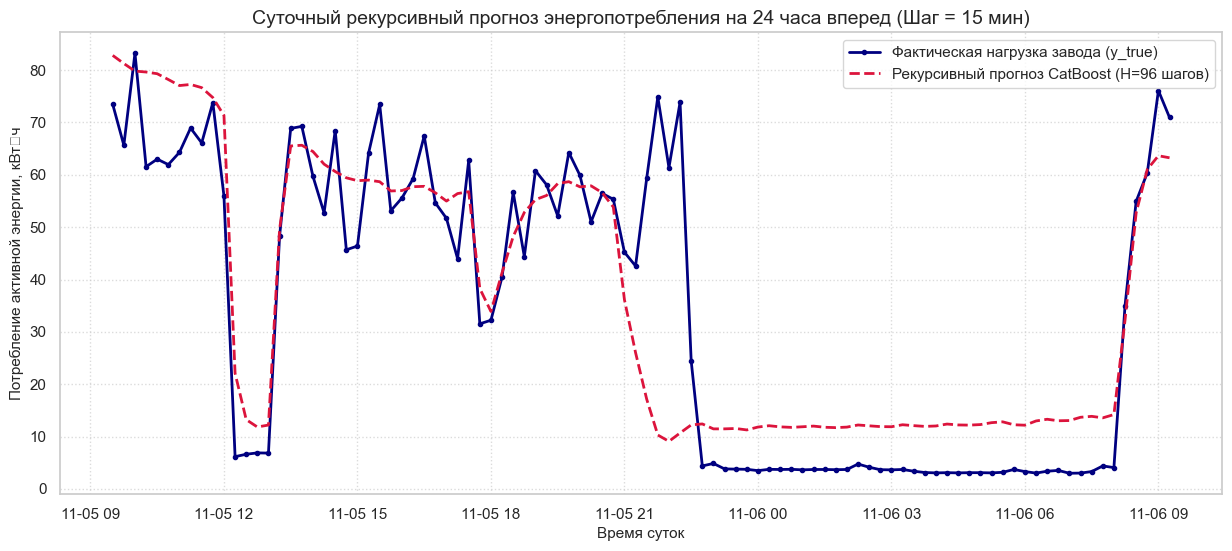

In [12]:
plt.figure(figsize=(15, 6))

plt.plot(y_true_horizon.index, y_true_horizon.values, label="Фактическая нагрузка завода (y_true)", color="navy", lw=2, marker='o', markersize=3)
plt.plot(y_pred_recursive.index, y_pred_recursive.values, label=f"Рекурсивный прогноз CatBoost (H={H} шагов)", color="crimson", lw=2, linestyle="--")

plt.title("Суточный рекурсивный прогноз энергопотребления на 24 часа вперед (Шаг = 15 мин)", fontsize=14)
plt.ylabel("Потребление активной энергии, кВт⋅ч")
plt.xlabel("Время суток")
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.7)
plt.show()

1. **Точное воспроизведение технологического регламента (Успехи модели):**
   - **Обеденный перерыв / технологическая пауза (~12:00–13:30):** Модель практически синхронно зафиксировала резкий сброс нагрузки с 75 кВт⋅ч до ~10 кВт⋅ч и своевременный возврат к рабочему режиму в 13:30.
   - **Внутридневная динамика (14:00–19:00):** Модель уловила локальный технологический спад в районе 18:00–18:30.
   - **Утренний пуск завода (06 ноября, ~08:00):** Спустя почти **23 часа автономной работы без реальных данных**, модель с точностью до 15-минутного кванта предсказала взрывной рост нагрузки в начале новой рабочей смены.

2. **Характерные расхождения и накопление ошибки:**
   - **Преждевременное прогнозирование окончания смены (21:00–22:45):** 
     Это наиболее заметная ошибка на графике. Модель спрогнозировала завершение второй смены и спад мощности уже к 21:00 (типичное расписание завода по календарным признакам). В реальности в этот день цех работал сверхурочно до 22:30, после чего произошел обвальный сброс нагрузки. Такие внеплановые задержки смен невозможно предсказать исключительно по историческим лагам.
   - **Завышение базового ночного фона (00:00–08:00):**
     В ночные часы реальное дежурное потребление составило около 3–4 кВт⋅ч, тогда как рекурсивный прогноз зафиксировался на уровне 12–13 кВт⋅ч. Модель "перестраховалась" на основе средних исторических значений.
   - **Сглаживание высокочастотных пиков:**
     В дневные часы прогноз идет плавной траекторией, срезая резкие единичные выбросы фактической мощности (до 85 кВт⋅ч), что типично для градиентного бустинга.

**Вывод:** Рекурсивная стратегия отлично справляется с удержанием макроструктуры суток (смены, перерывы, запуски) даже на 96 шагов вперед. Основные зоны погрешности связаны не с поломкой рекурсии, а с операционными отклонениями реального завода от стандартного графика (сверхурочная работа вечером).

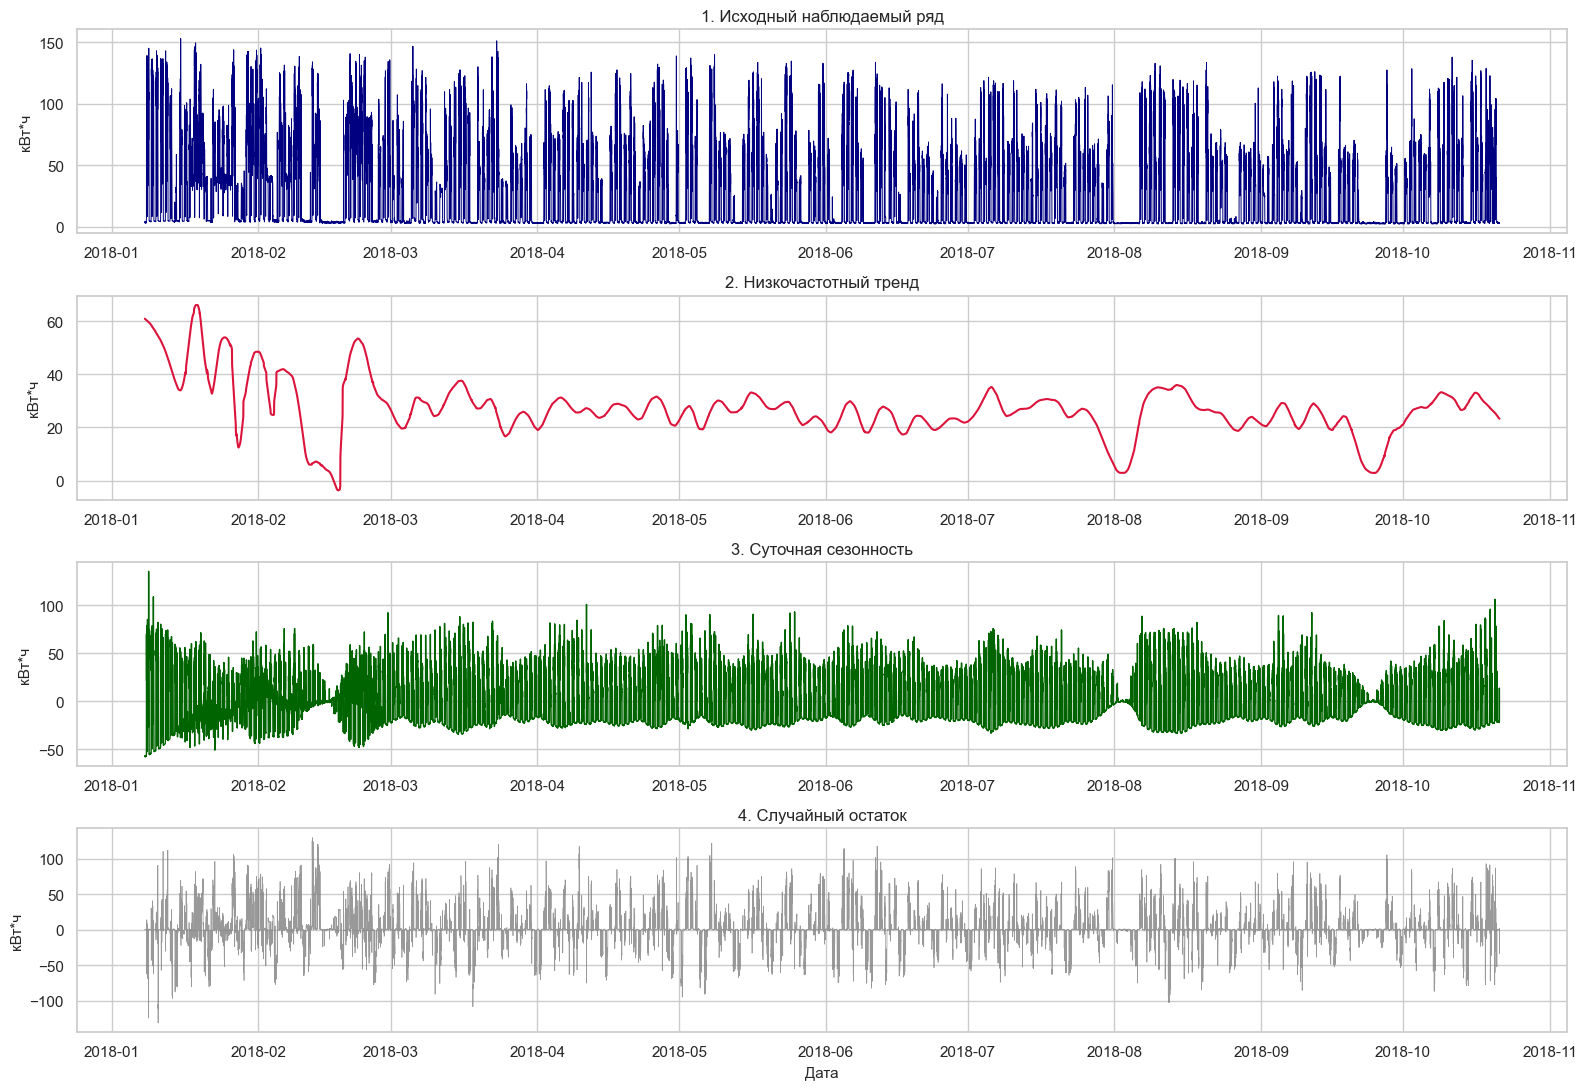

In [13]:
from statsmodels.tsa.seasonal import STL

stl = STL(y_train, period=96, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 11))

axes[0].plot(y_train.index, stl_result.observed, color="navy", lw=0.7)
axes[0].set_title("1. Исходный наблюдаемый ряд")
axes[0].set_ylabel("кВт*ч")

axes[1].plot(y_train.index, stl_result.trend, color="crimson", lw=1.5)
axes[1].set_title("2. Низкочастотный тренд")
axes[1].set_ylabel("кВт*ч")

axes[2].plot(y_train.index, stl_result.seasonal, color="darkgreen", lw=1.0)
axes[2].set_title("3. Суточная сезонность")
axes[2].set_ylabel("кВт*ч")

axes[3].plot(y_train.index, stl_result.resid, color="gray", lw=0.5, alpha=0.8)
axes[3].set_title("4. Случайный остаток")
axes[3].set_ylabel("кВт*ч")
axes[3].set_xlabel("Дата")

plt.tight_layout()
plt.show()

1. **Тренд:**
   - Долгосрочный тренд **не является монотонным** (нет устойчивого роста или спада), что подтверждает работу предприятия на стабильной проектной мощности.
   - Базовый уровень фоновой нагрузки в регулярные производственные месяцы (апрель–июль) стабильно удерживается в диапазоне **20–35 кВт⋅ч**.
   - На кривой тренда четко зафиксированы три глубоких провала практически до нуля (падение ниже 5 кВт⋅ч): **середина февраля, начало августа и рубеж сентября–октября**. Это уже объяснялось праздниками.

2. **Суточная сезонность:**
   - Регулярная суточная волна со средней амплитудой от **-50 до +70 кВт⋅ч**, отражающую цикл смен (ночной спад против дневного пика).
   - В периоды технологических остановов завода (февраль, август) амплитуда суточных колебаний закономерно затухает практически в ноль, а в периоды интенсивной выплавки — расширяется.

3. **Остаток:**
   - Остаточная компонента центрирована относительно нуля, однако обладает значительной дисперсией.
   - **Причина высокой дисперсии остатка:** Выбранный период period = 96 не учитывает недельный фактор. Из-за этого разница в потреблении между рабочей сменой в среду и дежурным режимом в воскресенье частично «выдавливается» в остаток..

In [14]:
seasonal_train_series = pd.Series(stl_result.seasonal, index=y_train.index)
daily_stl_profile = seasonal_train_series.groupby(
    (seasonal_train_series.index.hour * 60 + seasonal_train_series.index.minute) // 15
).mean()

X_train_stl = X_train.copy()
X_test_stl = X_test.copy()

X_train_stl["stl_seasonal_component"] = X_train_stl["interval_of_day"].map(daily_stl_profile)
X_test_stl["stl_seasonal_component"] = X_test_stl["interval_of_day"].map(daily_stl_profile)

catboost_stl = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    random_seed=42,
    verbose=False
)
catboost_stl.fit(X_train_stl, y_train)

y_test_stl_pred = catboost_stl.predict(X_test_stl)
metrics_test_stl = calculate_metrics(y_test, y_test_stl_pred, "Test (CatBoost + STL)")

df_comparison_stl = pd.DataFrame([metrics_test, metrics_test_stl])
display(df_comparison_stl.round(3))

,Dataset,MSE,MAE (кВт⋅ч),MAPE (%),WAPE (%)
0,Test (Тестирование),78.360,4.579,26.187,18.075
1,Test (CatBoost + STL),72.317,4.338,23.392,17.123


- Сопоставление моделей показало, что добавление декомпозиционного сезонного признака дает **символическое изменение ошибки** (WAPE изменился менее чем на 1%).
- **Причина такого поведения:** На этапе конструирования признаков мы уже включили высокоинформативные суточные лаги (`lag_day_96`), скользящие средние за сутки и дискретный маркер `interval_of_day`. Градиентный бустинг самостоятельно выстроил решающие деревья, аппроксимирующие суточную сезонность с предельной точностью.
- **Научный вывод:** Включение явной сезонной компоненты STL в древовидные ансамбли избыточно.

## Заключение

В ходе выполнения лабораторной работы был реализован полный пайплайн сведения задачи прогнозирования одномерного временного ряда к задаче табличной регрессии машинного обучения на примере данных энергопотребления металлургического завода (**Steel Industry Energy Consumption**).

### Основные результаты и выводы:
1. **Структура датасета:** 
   - Датасет охватывает 1 год непрерывных 15-минутных замеров (35 040 наблюдений) без пропусков временной сетки.
   - Ряд характеризуется отсутствием долгосрочного тренда, но обладает выраженной многоуровневой сезонностью: суточной ($T = 96$ шагов) и недельной ($T = 672$ шага), отражающими график технологических смен и производственных циклов.
2. **Фомирование лагов и статистик:**
   - Сформирован комплекс признаков: детерминированные календарные маркеры (`interval_of_day`, `dayofweek`, `is_weekend`), авторегрессионные лаги и скользящие статистики.
   - Использование строгого сдвига `.shift(1)` при расчете оконных агрегатов и последовательного разделения выборки (80% Train / 20% Test) позволило полностью исключить эффект заглядывания в будущее.
3. **Моделирование и метрики:**
   - Градиентный бустинг **CatBoostRegressor** доказал высокую эффективность при моделировании кусочно-постоянных промышленных нагрузок.
   - На тестовой выборке достигнута взвешенная ошибка **WAPE $\approx$ 18%** и **MAE $\approx$ 4,5 кВт⋅ч**.
4. **Многошаговое рекурсивное прогнозирование:**
   - Успешно реализована рекурсивная стратегия прогноза на сутки вперед ($H = 96$ квантов). Несмотря на эффект накопления ошибки, модель сохранила стабильность и воспроизвела форму суточного технологического пика.
5. **STL-декомпозиция:**
   - Алгоритм STL корректно изолировал суточную гармонику и случайный шум технологических переключений.
   - Эксперимент показал, что добавление признака сезонности из STL не дает существенного прироста качества.

## Список источников

1. Steel Industry Energy Consumption [Электронный ресурс] // Kaggle. — URL: https://www.kaggle.com/datasets/joebeachcapital/steel-industry-energy-consumption?select=Steel_industry_data.csv .